In [ ]:
import os
import sys
PROJECT_ROOT = '/storage/scratch1/3/grubin6/2AFC'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt


: 

In [3]:
from notebook_tools.io import read_ops


In [4]:
list_session_data_path = [
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_crux1_20250519_2afc-331',
    'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_lobulev_20250709_2afc-545',
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_simplex_20250528_2afc-373',
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_simplex_20250529_2afc-379',
    # 'F:\\Single_Interval_discrimination\\Data_2p\\YH24LG_CRBL_simplex_20250530_2afc-389',
]

list_ops = read_ops(list_session_data_path)

In [5]:
from notebook_tools.io import create_memmap, get_memmap_path, read_masks


In [6]:
# label -1 --> excitattory neurons, 1 --> inhibitory neuons

[labels, masks, mean_func, max_func, mean_anat, masks_anat] = read_masks(list_ops[0])

In [7]:
from notebook_tools.io import read_dff


In [8]:
dff = read_dff(list_ops[0])

In [9]:
from notebook_tools.io import read_raw_voltages


In [10]:
[vol_time, vol_start, vol_stim_vis, vol_img,
            vol_hifi, vol_stim_aud, vol_flir,
            vol_pmt, vol_led] = read_raw_voltages(list_ops[0])

In [11]:
from notebook_tools.io import read_bpod_mat_data


In [12]:
from notebook_tools.io import remove_start_impulse, correct_vol_start, get_trigger_time, get_session_start_time, correct_time_img_center, save_trials


In [13]:
print('Reading dff traces and voltage recordings')
# dff = read_dff(list_ops[0])
# [vol_time, vol_start, vol_stim_vis, vol_img,
#     vol_hifi, vol_stim_aud, vol_flir,
#     vol_pmt, vol_led] = read_raw_voltages(list_ops[0])
vol_stim_vis = remove_start_impulse(vol_time, vol_stim_vis)
vol_stim_vis = correct_vol_start(vol_stim_vis)
session_start_time = get_session_start_time(vol_time, vol_start)
trial_labels = read_bpod_mat_data(list_ops[0], session_start_time)
print('Correcting 2p camera trigger time')
# signal trigger time stamps.
time_img, _   = get_trigger_time(vol_time, vol_img)
# correct imaging timing.
time_neuro = correct_time_img_center(time_img)
# save the final data.
print('Saving trial data')
save_trials(
    list_ops[0], time_neuro, dff, trial_labels,
    vol_time, vol_stim_vis,
    vol_stim_aud, vol_flir,
    vol_pmt, vol_led)


Reading dff traces and voltage recordings
Correcting 2p camera trigger time
Saving trial data


In [14]:
from notebook_tools.io import read_trial_label, zscore_normalize, read_neural_trials


In [15]:
neural_trials = read_neural_trials(list_ops[0], 1)
trial_labels = read_trial_label(list_ops[0])

# plotting licking traces


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


n_trials = len(trial_labels['time_trial_start'])
trial_type = trial_labels['trial_type']
block_type = trial_labels['block_type']

# Collect licks aligned to each trial start
licks_per_trial = []
correctness_per_trial = []
for trial in range(n_trials):
    # Align to stim onset (you can adjust to trial start if needed)
    lick_times = (trial_labels['lick'][trial][0] - trial_labels['stim_seq'][trial][1][0])
    correctness = trial_labels['lick'][trial][2]  # e.g., 1 = correct, 0 = incorrect
    correctness_per_trial.append(correctness)
    licks_per_trial.append(lick_times)

# Remove NaNs for plotting
licks_per_trial = [lt[~np.isnan(lt)] for lt in licks_per_trial]

# Define colors per trial: green if majority correct, red otherwise
colors = []
for c in correctness_per_trial:
    # Handle empty or all-nan arrays
    if len(c) == 0 or np.all(np.isnan(c)):
        colors.append('gray')
    else:
        # Use mean correctness to decide color
        mean_corr = np.nanmean(c)
        colors.append('green' if mean_corr >= 0.5 else 'red')

# --- Raster plot ---
plt.figure(figsize=(10, 6))
plt.eventplot(licks_per_trial, colors=colors, linelengths=0.8)
plt.axvline(0, color='k', linestyle='--', label='Second Stimulus onset')

plt.xlabel('Time from stimulus onset (frames or s)')
plt.ylabel('Trial number')
plt.title('Lick raster aligned to stimulus onset\nGreen = correct, Red = incorrect')
plt.legend()
plt.tight_layout()
plt.show()


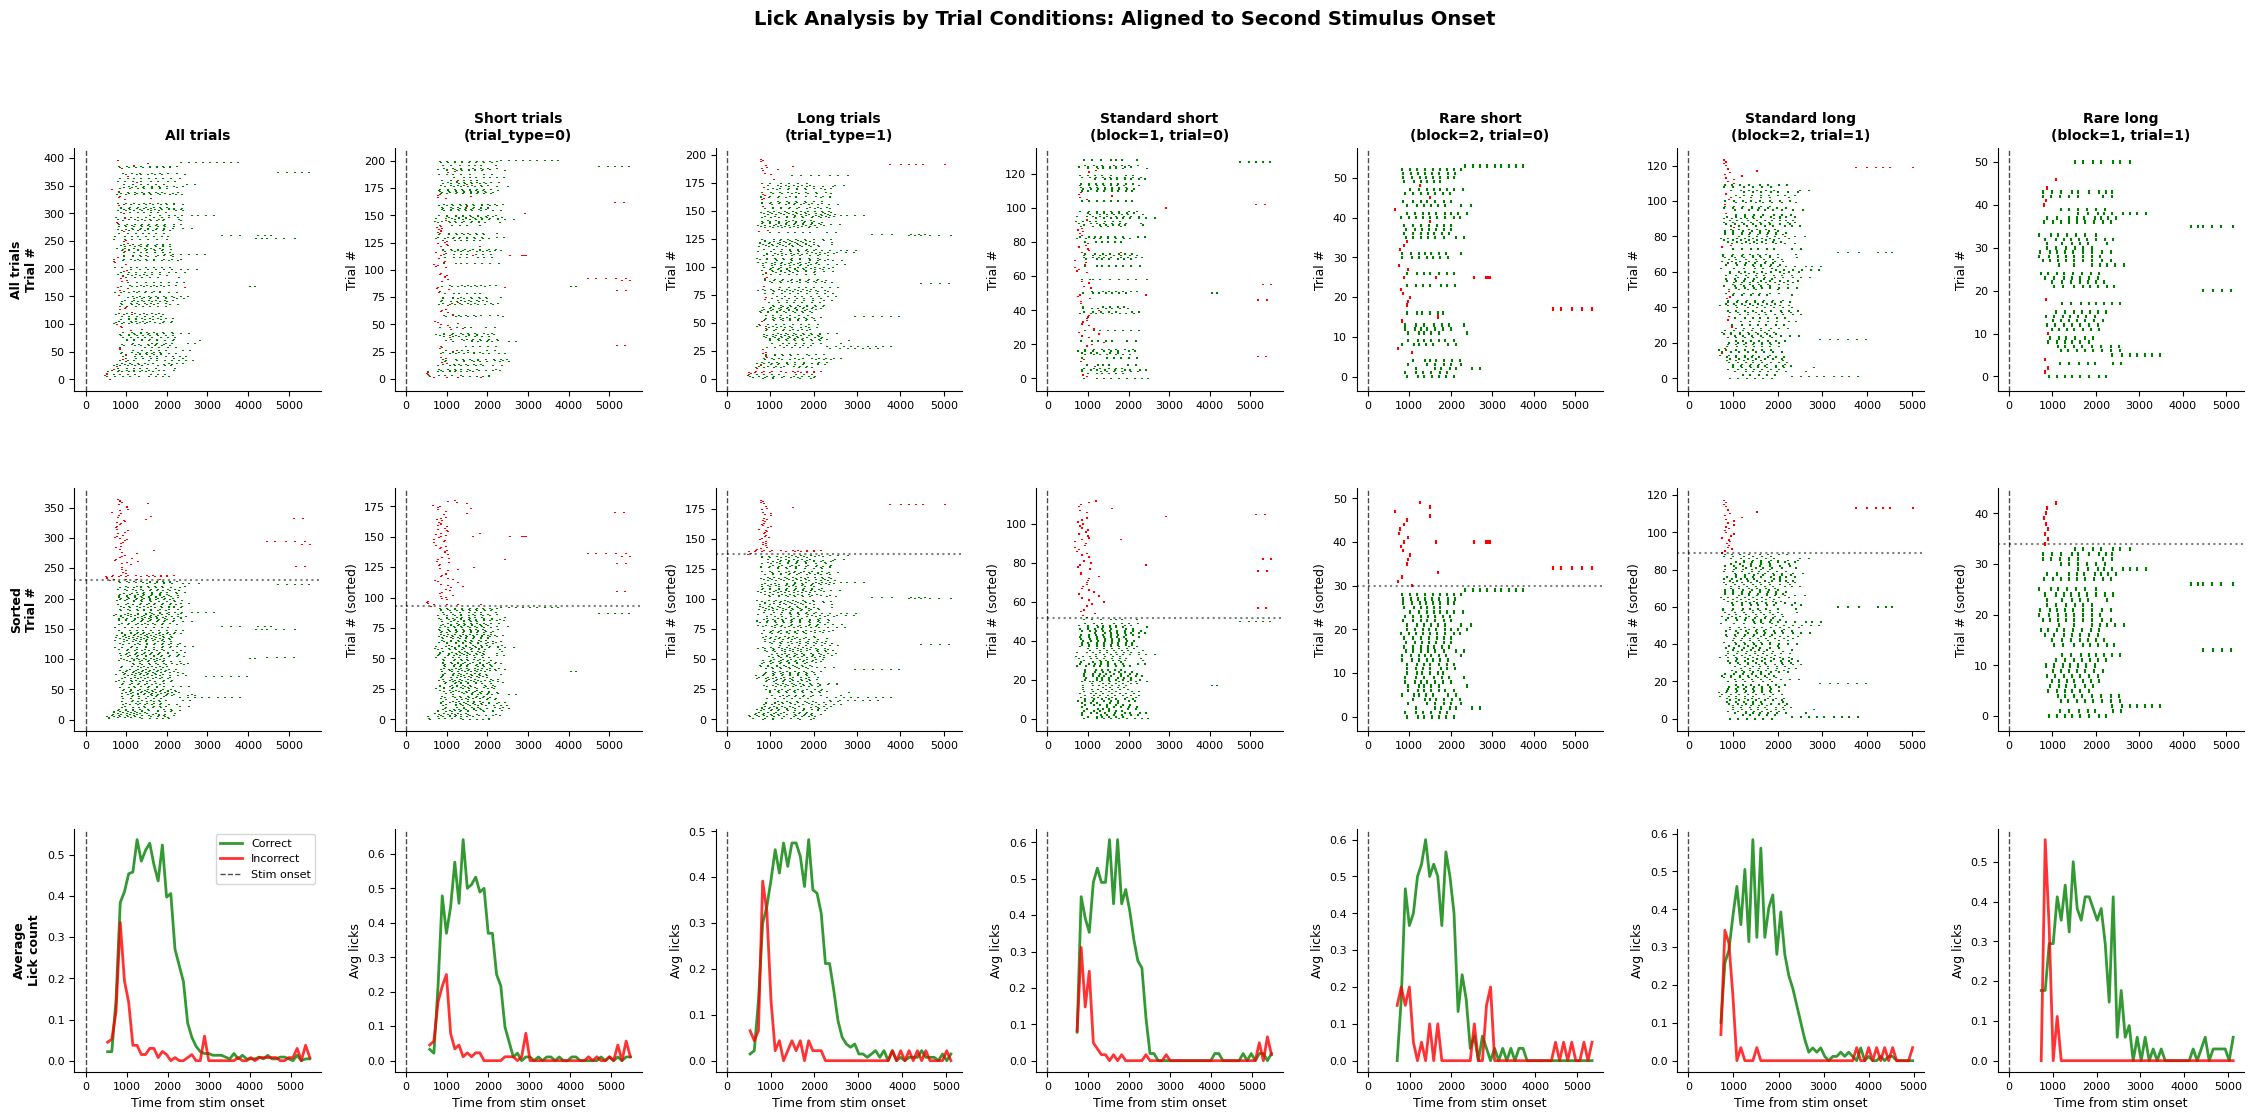

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

%matplotlib inline

n_trials = len(trial_labels['time_trial_start'])
trial_type = trial_labels['trial_type']
block_type = trial_labels['block_type']

# Collect licks aligned to each trial start
licks_per_trial = []
correctness_per_trial = []
for trial in range(n_trials):
    lick_times = (trial_labels['lick'][trial][0] - trial_labels['stim_seq'][trial][1][0])
    correctness = trial_labels['lick'][trial][2]
    correctness_per_trial.append(correctness)
    licks_per_trial.append(lick_times)

# Remove NaNs for plotting
licks_per_trial = [lt[~np.isnan(lt)] for lt in licks_per_trial]

# Define the 7 conditions
conditions = [
    {'name': 'All trials', 'mask': np.ones(n_trials, dtype=bool)},
    {'name': 'Short trials\n(trial_type=0)', 'mask': trial_type == 0},
    {'name': 'Long trials\n(trial_type=1)', 'mask': trial_type == 1},
    {'name': 'Standard short\n(block=1, trial=0)', 'mask': (block_type == 1) & (trial_type == 0)},
    {'name': 'Rare short\n(block=2, trial=0)', 'mask': (block_type == 2) & (trial_type == 0)},
    {'name': 'Standard long\n(block=2, trial=1)', 'mask': (block_type == 2) & (trial_type == 1)},
    {'name': 'Rare long\n(block=1, trial=1)', 'mask': (block_type == 1) & (trial_type == 1)}
]

# Create figure with gridspec
fig = plt.figure(figsize=(28, 12))
gs = GridSpec(3, 7, figure=fig, hspace=0.4, wspace=0.3)

# Process each condition (column)
for col_idx, condition in enumerate(conditions):
    mask = condition['mask']
    indices = np.where(mask)[0]
    
    if len(indices) == 0:
        # Skip if no trials match this condition
        for row in range(3):
            ax = fig.add_subplot(gs[row, col_idx])
            ax.text(0.5, 0.5, 'No trials', ha='center', va='center', fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(condition['name'], fontsize=10, fontweight='bold')
        continue
    
    # Get licks and correctness for this condition
    cond_licks = [licks_per_trial[i] for i in indices]
    cond_correctness = [correctness_per_trial[i] for i in indices]
    
    # Determine colors for each trial
    colors = []
    for c in cond_correctness:
        if len(c) == 0 or np.all(np.isnan(c)):
            colors.append('gray')
        else:
            mean_corr = np.nanmean(c)
            colors.append('green' if mean_corr >= 0.5 else 'red')
    
    # --- Row 1: All trials raster ---
    ax1 = fig.add_subplot(gs[0, col_idx])
    ax1.eventplot(cond_licks, colors=colors, linelengths=0.8)
    ax1.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7)
    ax1.set_ylabel('Trial #', fontsize=9)
    # Remove top and right spines for cleaner look
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    if col_idx == 0:
        ax1.set_ylabel('All trials\nTrial #', fontsize=9, fontweight='bold')
    ax1.set_title(condition['name'], fontsize=10, fontweight='bold')
    ax1.tick_params(labelsize=8)
    
    # --- Row 2: Sorted by correctness (correct then incorrect) ---
    ax2 = fig.add_subplot(gs[1, col_idx])
    
    # Separate correct and incorrect trials
    correct_indices = [i for i, c in enumerate(cond_correctness) 
                       if len(c) > 0 and not np.all(np.isnan(c)) and np.nanmean(c) >= 0.5]
    incorrect_indices = [i for i, c in enumerate(cond_correctness) 
                         if len(c) > 0 and not np.all(np.isnan(c)) and np.nanmean(c) < 0.5]
    
    # Sort: correct first, then incorrect
    sorted_indices = correct_indices + incorrect_indices
    sorted_licks = [cond_licks[i] for i in sorted_indices]
    sorted_colors = ['green'] * len(correct_indices) + ['red'] * len(incorrect_indices)
    
    if len(sorted_licks) > 0:
        ax2.eventplot(sorted_licks, colors=sorted_colors, linelengths=0.8)
        ax2.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7)
        # Add horizontal line separating correct/incorrect
        if len(correct_indices) > 0 and len(incorrect_indices) > 0:
            ax2.axhline(len(correct_indices), color='black', linestyle=':', linewidth=1.5, alpha=0.5)
    
    ax2.set_ylabel('Trial # (sorted)', fontsize=9)
    if col_idx == 0:
        ax2.set_ylabel('Sorted\nTrial #', fontsize=9, fontweight='bold')
    ax2.tick_params(labelsize=8)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # --- Row 3: Average lick rate line plot ---
    ax3 = fig.add_subplot(gs[2, col_idx])
    
    # Calculate time bins
    all_lick_times = np.concatenate([lt for lt in cond_licks if len(lt) > 0])
    if len(all_lick_times) > 0:
        time_min, time_max = all_lick_times.min(), all_lick_times.max()
        time_bins = np.linspace(time_min, time_max, 50)
        bin_centers = (time_bins[:-1] + time_bins[1:]) / 2
        
        # Calculate average for correct trials
        if len(correct_indices) > 0:
            correct_licks = [cond_licks[i] for i in correct_indices]
            correct_counts = []
            for lt in correct_licks:
                if len(lt) > 0:
                    hist, _ = np.histogram(lt, bins=time_bins)
                    correct_counts.append(hist)
            if correct_counts:
                avg_correct = np.mean(correct_counts, axis=0)
                ax3.plot(bin_centers, avg_correct, 'g-', linewidth=2, label='Correct', alpha=0.8)
        
        # Calculate average for incorrect trials
        if len(incorrect_indices) > 0:
            incorrect_licks = [cond_licks[i] for i in incorrect_indices]
            incorrect_counts = []
            for lt in incorrect_licks:
                if len(lt) > 0:
                    hist, _ = np.histogram(lt, bins=time_bins)
                    incorrect_counts.append(hist)
            if incorrect_counts:
                avg_incorrect = np.mean(incorrect_counts, axis=0)
                ax3.plot(bin_centers, avg_incorrect, 'r-', linewidth=2, label='Incorrect', alpha=0.8)
    
    ax3.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stim onset')
    ax3.set_xlabel('Time from stim onset', fontsize=9)
    ax3.set_ylabel('Avg licks', fontsize=9)
    if col_idx == 0:
        ax3.set_ylabel('Average\nLick count', fontsize=9, fontweight='bold')
        ax3.legend(fontsize=8, loc='best')
    ax3.tick_params(labelsize=8)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    # ax3.grid(True, alpha=0.3)

plt.suptitle('Lick Analysis by Trial Conditions: Aligned to Second Stimulus Onset', 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()